In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import classification_report, accuracy_score

# Reading data

In [2]:
df=pd.read_csv("/kaggle/input/unlock-profits-with-e-commerce-sales-data/Amazon Sale Report.csv")
df = df.drop(columns=['Unnamed: 22','index','Order ID','SKU','currency','ship-state','promotion-ids','ship-country','ship-postal-code','fulfilled-by'])
df.head(2).T

<ipython-input-2-4a25da7b023b>:1: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("/kaggle/input/unlock-profits-with-e-commerce-sales-data/Amazon Sale Report.csv")


,0,1
Date,04-30-22,04-30-22
Status,Cancelled,Shipped - Delivered to Buyer
Fulfilment,Merchant,Merchant
Sales Channel,Amazon.in,Amazon.in
ship-service-level,Standard,Standard
Style,SET389,JNE3781
Category,Set,kurta
Size,S,3XL
ASIN,B09KXVBD7Z,B09K3WFS32
Courier Status,NaN,Shipped


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Date                128975 non-null  object 
 1   Status              128975 non-null  object 
 2   Fulfilment          128975 non-null  object 
 3   Sales Channel       128975 non-null  object 
 4   ship-service-level  128975 non-null  object 
 5   Style               128975 non-null  object 
 6   Category            128975 non-null  object 
 7   Size                128975 non-null  object 
 8   ASIN                128975 non-null  object 
 9   Courier Status      122103 non-null  object 
 10  Qty                 128975 non-null  int64  
 11  Amount              121180 non-null  float64
 12  ship-city           128942 non-null  object 
 13  B2B                 128975 non-null  bool   
dtypes: bool(1), float64(1), int64(1), object(11)
memory usage: 12.9+ MB


# Understanding the data

### The visualization shows a peak at 2022-5-4

<ipython-input-4-235e9d0c6e5b>:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


<Axes: title={'center': 'Orders Over Time'}, xlabel='Date'>

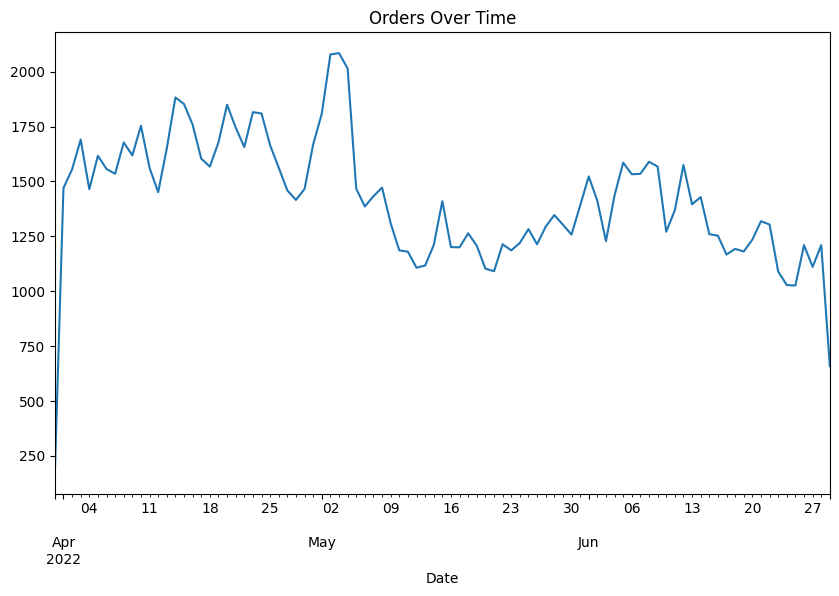

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'].value_counts().sort_index().plot(kind='line', figsize=(10, 6), title='Orders Over Time')

### The cumulative sales over time is incressing

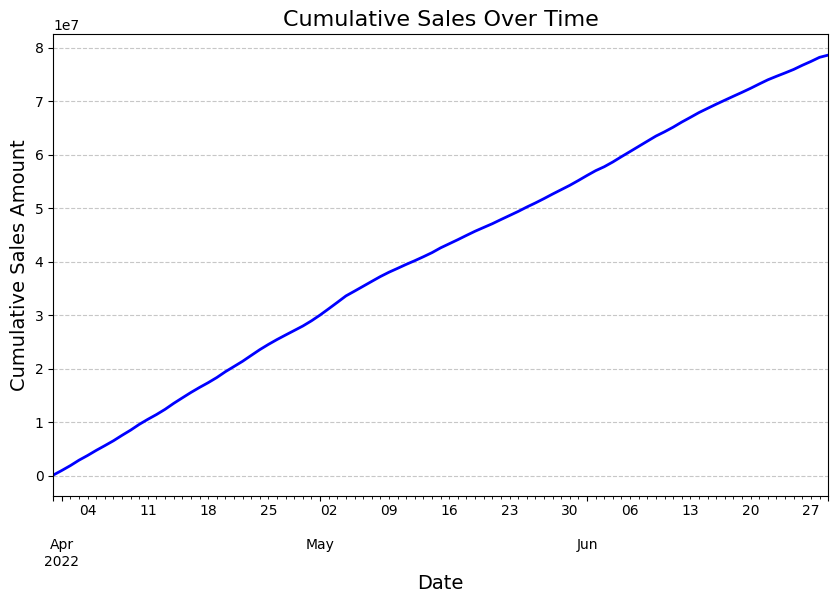

In [5]:
# Aggregate sales by date and calculate the cumulative sum
daily_sales = df.groupby('Date')['Amount'].sum().sort_index()
cumulative_sales = daily_sales.cumsum()

# Plot the cumulative sales
plt.figure(figsize=(10, 6))
cumulative_sales.plot(kind='line', color='blue', linewidth=2)
plt.title('Cumulative Sales Over Time', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Cumulative Sales Amount', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### the top selling size M and L

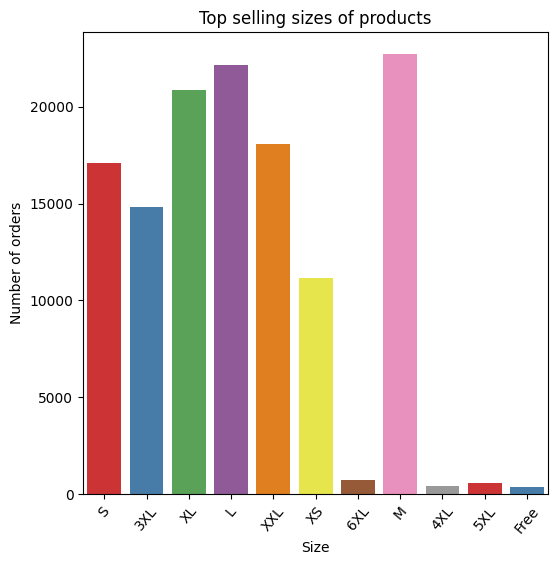

In [6]:
plt.figure(figsize=(6, 6))
sns.countplot(x=df['Size'],data=df,palette='Set1')

plt.xlabel('Size')
plt.ylabel('Number of orders')
plt.title('Top selling sizes of products')
plt.xticks(rotation=50)

plt.show()

### This visualization indicates the presence of outliers because the distribution is not centered

<Axes: title={'center': 'Order Amount Distribution'}, ylabel='Frequency'>

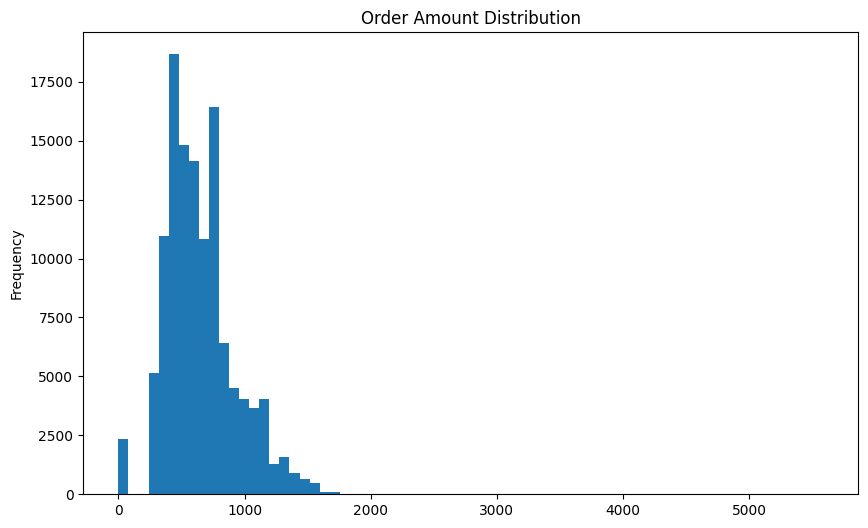

In [7]:
df['Amount'].plot(kind='hist', bins=70, figsize=(10, 6), title='Order Amount Distribution')

### here is  a better vis that shows the outlier values

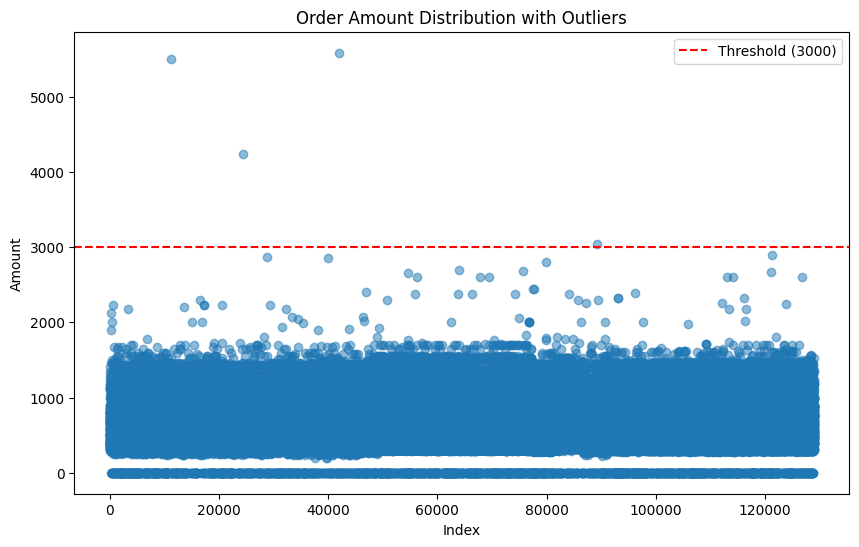

In [8]:
# Create a scatter plot for 'Amount' to visualize outliers
plt.figure(figsize=(10, 6))
plt.scatter(df.index, df['Amount'], alpha=0.5)
plt.axhline(y=3000, color='r', linestyle='--', label='Threshold (3000)')
plt.title('Order Amount Distribution with Outliers')
plt.xlabel('Index')
plt.ylabel('Amount')
plt.legend()
plt.show()

# the status of the order shows many canceld order

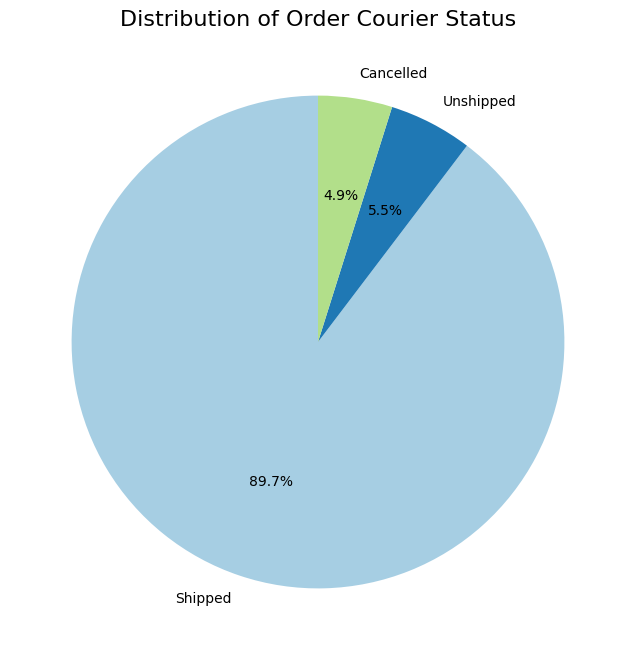

In [10]:
# Count the occurrences of each status
status_counts = df['Courier Status'].value_counts()

# Plot the pie chart
plt.figure(figsize=(8, 8))
status_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('Distribution of Order Courier Status', fontsize=16)
plt.ylabel('')  # Remove the y-axis label for a cleaner look
plt.show()

In [11]:
cancelled_orders = df[df['Status'] == 'Cancelled']
cancelled_orders.head(2)

,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,Category,Size,ASIN,Courier Status,Qty,Amount,ship-city,B2B
0,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,Set,S,B09KXVBD7Z,NaN,0,647.62,MUMBAI,False
3,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,Western Dress,L,B099NRCT7B,NaN,0,753.33,PUDUCHERRY,False


### this vis : shows Shipping Service Levels ,we want to minimize the standerd

<Axes: title={'center': 'Shipping Service Levels'}, xlabel='ship-service-level'>

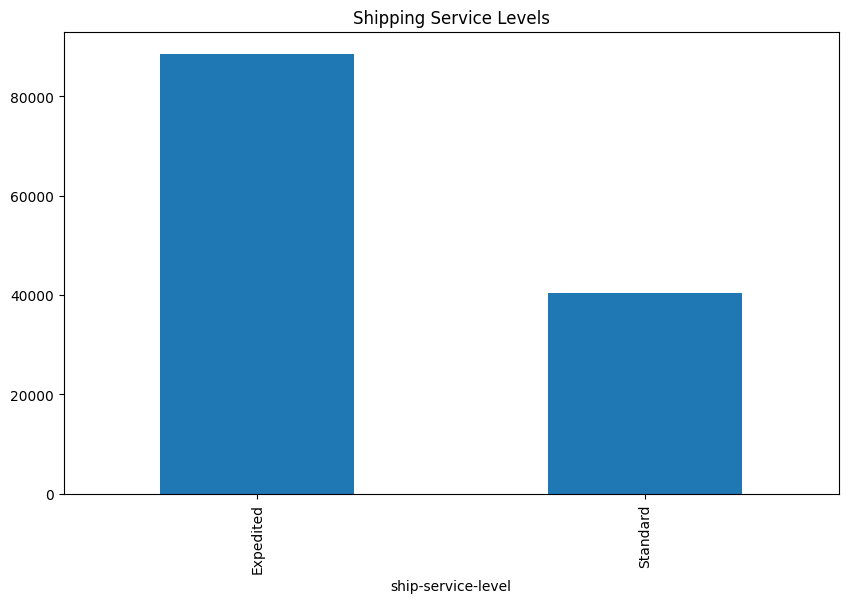

In [12]:
df['ship-service-level'].value_counts().plot(kind='bar', figsize=(10, 6), title='Shipping Service Levels')

### In the visulization "sets" is the must bought thing

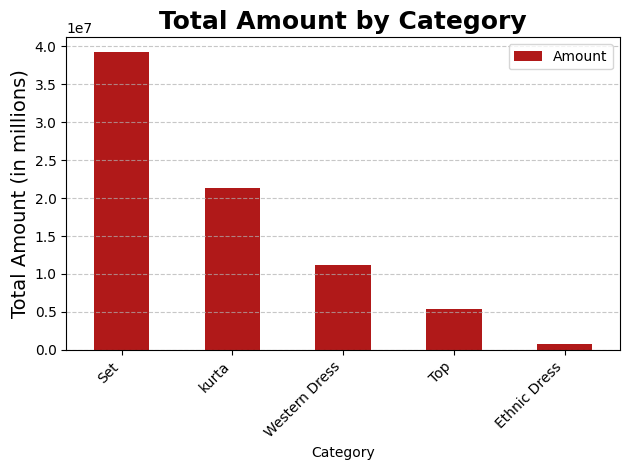

In [13]:
Top5_Trending_product=df.groupby('Category')['Amount'].sum().to_frame().sort_values(by=['Amount'],ascending=False).head(5)
Top5_Trending_product.plot(kind='bar',color='#b01919')
plt.title('Total Amount by Category', fontsize=18, weight='bold')
plt.ylabel('Total Amount (in millions)', fontsize=14)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
#creating more useful column that can make better impact on the Machine learning model
df['Month'] = df['Date'].dt.month

In [15]:
df['Courier Status'].value_counts()

Courier Status
Shipped      109487
Unshipped      6681
Cancelled      5935
Name: count, dtype: int64

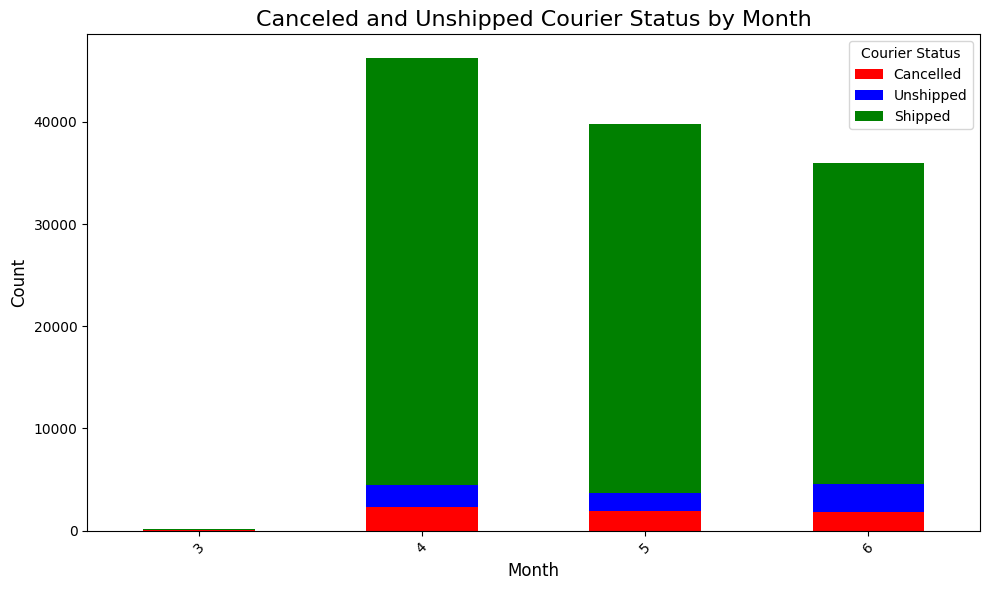

In [16]:
# Compute counts for each Month and Courier Status
grouped_data = df.groupby(['Month', 'Courier Status']).size().reset_index(name='Count')

# Pivot the data for plotting
pivot_data = grouped_data.pivot(index='Month', columns='Courier Status', values='Count').fillna(0)

# Plot the data
pivot_data[['Cancelled', 'Unshipped','Shipped']].plot(kind='bar', figsize=(10, 6), stacked=True, color=['red', 'blue','green'])

# Add titles and labels
plt.title("Canceled and Unshipped Courier Status by Month", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Courier Status")
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()


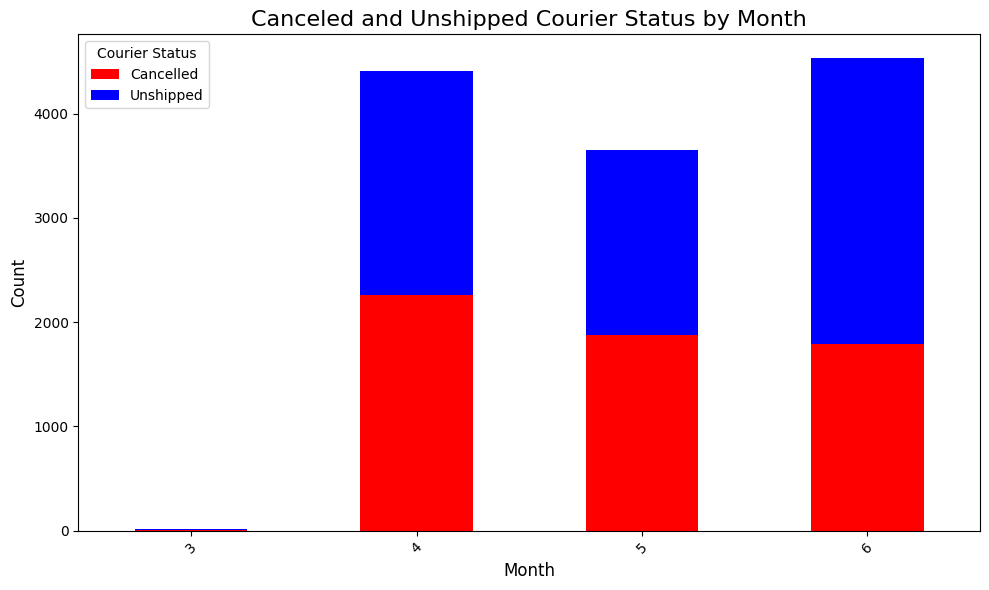

In [17]:
# Compute counts for each Month and Courier Status
grouped_data = df.groupby(['Month', 'Courier Status']).size().reset_index(name='Count')

# Pivot the data for plotting
pivot_data = grouped_data.pivot(index='Month', columns='Courier Status', values='Count').fillna(0)

# Plot the data
pivot_data[['Cancelled', 'Unshipped']].plot(kind='bar', figsize=(10, 6), stacked=True, color=['red', 'blue'])

# Add titles and labels
plt.title("Canceled and Unshipped Courier Status by Month", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Courier Status")
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()


# Now let's preprocess the data

In [19]:
# Step 1: Drop unnecessary columns 
df = df.drop(columns=['Date'])

In [20]:
# 2-check the null values
df.isnull().sum()

Status                   0
Fulfilment               0
Sales Channel            0
ship-service-level       0
Style                    0
Category                 0
Size                     0
ASIN                     0
Courier Status        6872
Qty                      0
Amount                7795
ship-city               33
B2B                      0
Month                    0
dtype: int64

In [21]:
df['Courier Status'].value_counts()

Courier Status
Shipped      109487
Unshipped      6681
Cancelled      5935
Name: count, dtype: int64

In [22]:
df['ship-city'].value_counts()

ship-city
BENGALURU                                      11217
HYDERABAD                                       8074
MUMBAI                                          6126
NEW DELHI                                       5795
CHENNAI                                         5421
                                               ...  
Khandavalli, peravali mandal, west godavari        1
Bhayander west                                     1
JAKHALMANDI                                        1
Arariya                                            1
Halol                                              1
Name: count, Length: 8955, dtype: int64

In [23]:
df['ship-city'].mode()

0    BENGALURU
Name: ship-city, dtype: object

In [24]:
df['Amount'].median()

605.0

### vis that shows the columns that has many nulls

<Axes: >

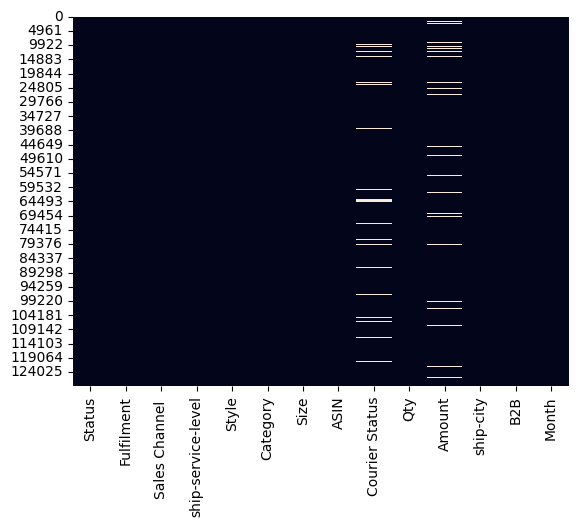

In [25]:
sns.heatmap(df.isnull(),cbar=False)

In [26]:
# Step 3: Replace remaining null values
# For numerical columns, you can replace nulls with the median
df['Courier Status'] = df['Courier Status'].fillna(df['Courier Status'].mode()[0])
df['Amount'] = df['Amount'].fillna(df['Amount'].median())
df['ship-city'] = df['ship-city'].fillna(df['ship-city'].mode()[0])  # Using mode for categorical

# Let's prepare for the Machine Learning Model

### the model will predict the status --> shipped , unshipped , cancelled

In [27]:
data = df.copy()

In [28]:
data

,Status,Fulfilment,Sales Channel,ship-service-level,Style,Category,Size,ASIN,Courier Status,Qty,Amount,ship-city,B2B,Month
0,Cancelled,Merchant,Amazon.in,Standard,SET389,Set,S,B09KXVBD7Z,Shipped,0,647.62,MUMBAI,False,4
1,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,kurta,3XL,B09K3WFS32,Shipped,1,406.00,BENGALURU,False,4
2,Shipped,Amazon,Amazon.in,Expedited,JNE3371,kurta,XL,B07WV4JV4D,Shipped,1,329.00,NAVI MUMBAI,True,4
3,Cancelled,Merchant,Amazon.in,Standard,J0341,Western Dress,L,B099NRCT7B,Shipped,0,753.33,PUDUCHERRY,False,4
4,Shipped,Amazon,Amazon.in,Expedited,JNE3671,Top,3XL,B098714BZP,Shipped,1,574.00,CHENNAI,False,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128970,Shipped,Amazon,Amazon.in,Expedited,JNE3697,kurta,XL,B098112V2V,Shipped,1,517.00,HYDERABAD,False,5
128971,Shipped,Amazon,Amazon.in,Expedited,SET401,Set,M,B09VC6KHX8,Shipped,1,999.00,GURUGRAM,False,5
128972,Shipped,Amazon,Amazon.in,Expedited,J0157,Western Dress,XXL,B0982YZ51B,Shipped,1,690.00,HYDERABAD,False,5
128973,Shipped,Amazon,Amazon.in,Expedited,J0012,Set,XS,B0894Y2NJQ,Shipped,1,1199.00,Halol,False,5


In [29]:
# replace the categrical values with numbers
# bec ML accept numbers only
# Define the mapping dictionary
status_map = {
    'Shipped': 0,
    'Shipped - Delivered to Buyer': 1,
    'Cancelled': 2,
    'Shipped - Returned to Seller': 3,
    'Shipped - Picked Up': 4,
    'Pending': 5,
    'Pending - Waiting for Pick Up': 6,
    'Shipped - Returning to Seller': 7,
    'Shipped - Out for Delivery': 8,
    'Shipped - Rejected by Buyer': 9,
    'Shipping': 10,
    'Shipped - Lost in Transit': 11,
    'Shipped - Damaged': 12
}
category_map = {'Set': 1,'kurta': 2,'Western Dress': 3,'Top': 4,'Ethnic Dress': 5,'Blouse': 6,'Bottom': 7,'Saree': 8,'Dupatta': 9}
sales_channel_map = {'Amazon.in': 1,'Non-Amazon': 0}
B2B_map = { False : 0 , True : 1 }
categorystat_map = {'Shipped': 1, 'Unshipped': 0 , 'Cancelled' : -1}
Fulfilment_map = { 'Amazon' : 1 ,'Merchant' : 0 }
ship_service_level_map = { 'Expedited' : 1 , 'Standard' : 0}

data['Category'] = data['Category'].map(category_map)
data['Sales Channel '] = data['Sales Channel '].map(sales_channel_map)
data['Status'] = data['Status'].map(status_map)
data['Courier Status'] = df['Courier Status'].map(categorystat_map)
data['B2B']=df['B2B'].map(B2B_map)
data['Fulfilment']=df['Fulfilment'].map(Fulfilment_map)
data['ship-service-level']=df['ship-service-level'].map(ship_service_level_map)

In [30]:
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols

['Status',
 'Fulfilment',
 'Sales Channel ',
 'ship-service-level',
 'Category',
 'Courier Status',
 'Qty',
 'Amount',
 'B2B']

In [31]:
cols=['Status','Fulfilment','Sales Channel ','ship-service-level','Qty','Amount','Category',
 'Courier Status','B2B','Month']

X = data[cols] 
Y = data['Courier Status'] 
 
X_train, X_test, y_train, y_test = train_test_split(X, Y,test_size=0.2, random_state=45)

In [32]:
X_train

,Status,Fulfilment,Sales Channel,ship-service-level,Qty,Amount,Category,Courier Status,B2B,Month
35940,0,1,1,1,1,597.0,1,1,0,4
30922,0,1,1,1,1,459.0,2,1,0,4
116669,0,1,1,1,1,560.0,1,1,0,6
48437,0,1,1,1,1,1130.0,1,1,0,4
16592,0,1,1,1,1,950.0,1,1,0,4
...,...,...,...,...,...,...,...,...,...,...
60960,0,1,1,1,1,791.0,3,1,0,5
6012,1,0,1,0,1,744.0,3,1,0,4
63107,1,0,1,0,1,771.0,3,1,0,5
6558,0,1,1,1,1,999.0,3,1,0,4


In [33]:
y_train

35940     1
30922     1
116669    1
48437     1
16592     1
         ..
60960     1
6012      1
63107     1
6558      1
121803    1
Name: Courier Status, Length: 103180, dtype: int64

# Train the model using Random Forest Model

In [35]:
# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=45)  # n_estimators is the number of trees
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

# Evaluate Random Forest Model
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_predictions))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))


Random Forest Classification Report:
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00      1208
           0       1.00      1.00      1.00      1335
           1       1.00      1.00      1.00     23252

    accuracy                           1.00     25795
   macro avg       1.00      1.00      1.00     25795
weighted avg       1.00      1.00      1.00     25795

Random Forest Accuracy: 1.0
